In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

import json

from settings import x_token, s_token, host, postgre_bd, user, psw
import funcs_yum as fy

In [2]:
posgdb = fy.PostgresDB(host, postgre_bd, user, psw)

# main

In [3]:
main_anime_df = pd.read_sql_query(
    '''
    SELECT *
    FROM anime_main
    ORDER BY anime_id
    ''',
    posgdb.conn
)

main_copy = main_anime_df.copy()

C:\Users\gusen\AppData\Local\Temp\ipykernel_22972\3645262620.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  main_anime_df = pd.read_sql_query(


In [20]:
main_anime_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10197 entries, 0 to 10196
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   anime_id         10197 non-null  int64
 1   title            10197 non-null  str  
 2   description      10197 non-null  str  
 3   duration         10197 non-null  int64
 4   anime_url        10197 non-null  str  
 5   year             10197 non-null  int64
 6   season           10197 non-null  int64
 7   views            10197 non-null  int64
 8   status_ru        10197 non-null  str  
 9   type_ru          10197 non-null  str  
 10  rating_all       10197 non-null  int64
 11  rating_category  10197 non-null  int64
 12  original_source  10197 non-null  str  
 13  episodes_count   10197 non-null  int64
 14  comments_count   10197 non-null  int64
 15  lists_count      10197 non-null  int64
dtypes: int64(10), str(6)
memory usage: 1.2 MB


In [5]:
main_anime_df.head()

,anime_id,title,description,duration,anime_url,year,season,views,status_ru,type_ru,rating_all,rating_category,original_source,episodes_count,comments_count,lists_count
0,1,Ведьма-неудачница: Фука и тёмная ведьма,"Фука — неуклюжая принцесса, прозванная «Ведьмо...",3579,22-7,2023,1,47612,вышел,Короткометражный фильм,8243,1220,Новелла,1,3,487
1,2,5 сантиметров в секунду,"Что происходит, когда два человека любят друг ...",3766,5-santimetrov-v-sekundu,2007,2,259721,вышел,Полнометражный фильм,7356,1162,Оригинальная идея,1,270,14399
2,3,"А ты думал, что твоя жена в онлайн-игре на сам...",В центре сюжета как обычно простой школьник-по...,17711,a-ty-dumal-chto-tvoya-zhena-v-onlajn-igre-na-s...,2016,2,244225,вышел,Сериал,10130,4060,Ранобэ,12,155,9350
3,4,A3! Осень и зима,"Компания «Манкай» далека от тех славных дней, ...",17124,a3-osen-i-zima,2020,4,32503,вышел,Сериал,6625,2680,Игра,12,3,385
4,5,A3! Весна и лето,"Театр «Манкай» находится на грани разорения, н...",17149,a3-vesna-i-leto,2020,1,27999,вышел,Сериал,4753,2130,Игра,12,0,684


## Всего на момент выгрузки на сайте было 10197 разных тайтлов 

## Распределение аниме по году выпуска
Тут можно указать две даты, после которы начинается рост количества выпускаемых аниме: 
- с 1985 начали выпускать аниме сразу на касетах без показа на больших экранах
- в 2000 наклыдывается множество факторов: переход к цифровой рисовке, развитие жанров для взрослой аудитории, 
    переход от длиносерийного производства (100+ серий) к более короткому формату (12/24 серий)

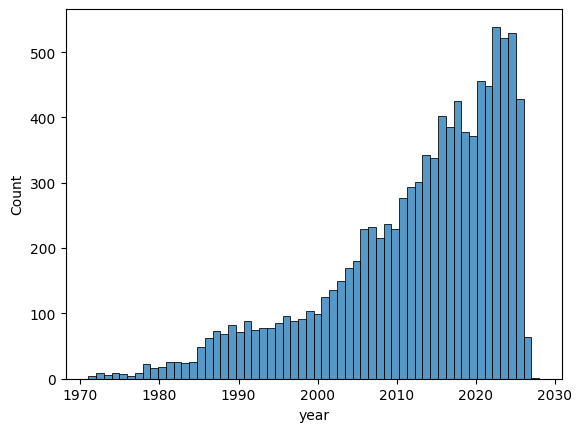

In [40]:
mask = main_anime_df['year']>1970
data = main_anime_df[mask].groupby('year')['anime_id'].count()

n_bins = len(data)
sns.histplot(main_anime_df[mask]['year'], bins=n_bins)

plt.title('')
plt.show()

## Распределение аниме по периодам года 

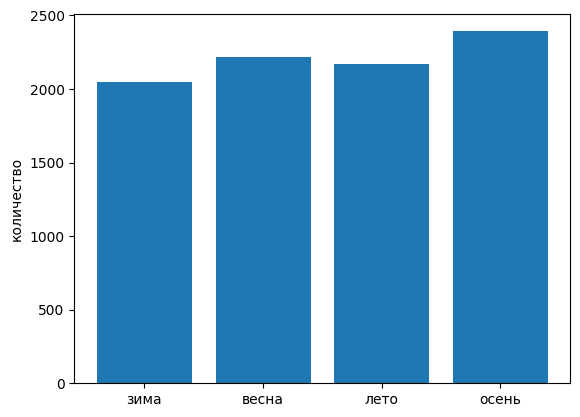

In [61]:
# season (зима, весна, лето, осень)
season = {1:'зима', 2:'весна', 3:'лето', 4:'осень'}

mask = main_anime_df['season']>0
data = main_anime_df[mask].groupby('season')['anime_id'].count()
data = data.rename(index=season)

n_bins = len(data)
plt.bar(data.index, data)

plt.title('')
plt.ylabel('количество')
plt.show()

## Распределение аниме по продолжительности (в секундах)

На распределениии по продолжительности выделяются три пика  
Эти пики можно охарактеризовать, если принять что в среднем в аниме сериале серии длятся по 24-25 минут  
тогда 3 группы это:
1) 34.000 - 38.000 секунд = 570 - 640 минут = 24/25 серии в среднем (с учетом средней длительности 1 серии)
2) 17.000 - 19.000 секунд = 280 - 320 минут = 12/13 серии в среднем
3) < 8000 = 130 минут 

Т.е. Среди всех аниме больше всего 12 и 24 серийников, + группа аниме длительностью менее двух часов (фильмы, короткие сериалы < 6 серий)

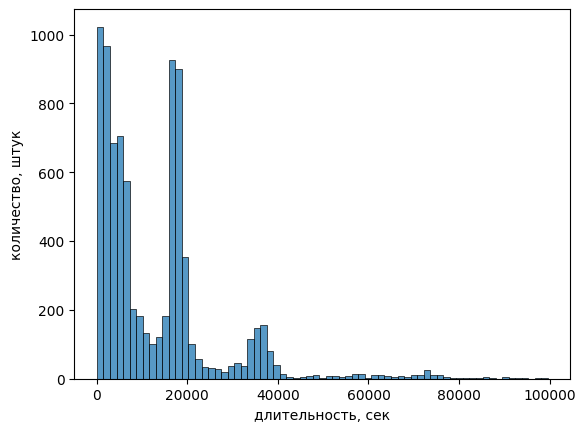

In [62]:
mask1 = main_anime_df['duration']>0
mask2 = main_anime_df['duration']<100000

sns.histplot(main_anime_df['duration'].where(mask1 & mask2))

plt.title('')
plt.xlabel('длительность, сек')
plt.ylabel('количество, штук')
plt.show()

При детальном рассмотрении группы, в которой продолжительность < 8000 секунд  
так же можно выделить 3 группы:  
1) 5.000 - 7.000 секунд = 80 - 120 минут - это полнометражные фильмы
2) 2600 -3400 секунд = 40 - 60 минут - либо 2 серии спешиала, либо 1 более длинный выпуск
3) 1500 - 1800 секунд = 25 - 30 минут - 1 серийные выпуски (спешиалы, ответвления)

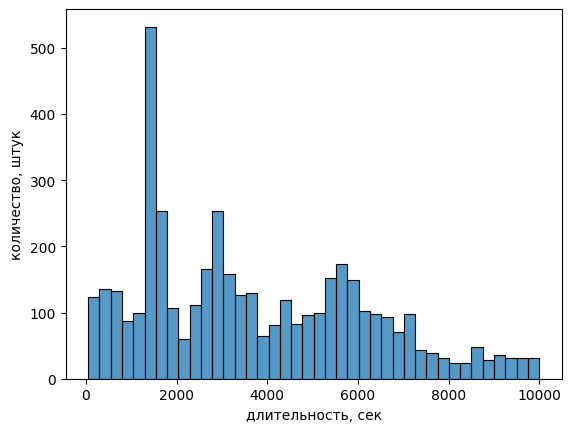

In [64]:
mask1 = main_anime_df['duration']>000
mask2 = main_anime_df['duration']<10000

sns.histplot(main_anime_df['duration'].where(mask1 & mask2), bins=40)

plt.title('')
plt.xlabel('длительность, сек')
plt.ylabel('количество, штук')
plt.show()

И есть под 100 штук аниме, общая длительность которых более 24 часов, зачастую там несколько сотен серий  
из наиболее известных это Наруто и Блич

In [123]:
mask1 = main_anime_df['duration']>1e5

main_anime_df[mask1][['title', 'duration']].sort_values(by='duration', ascending=False).head(7)

,title,duration
1457,Детектив Конан,1775211
1201,Ван-Пис,1698197
101,Наруто: Ураганные хроники,835438
79,Блич,545842
9020,Операция: Семейка Ёдзакура 2,491615
245,Драконий жемчуг Z,430638
116,Боруто: Новое Поколение,426777


## Распределение аниме по количеству простмотров страцы аниме

показывает популярность тех или иных аниме  
всего на сайте в сумме под 900 миллионов посещений разных аниме  
больше 1 миллиона посещений имеют 135 тайтлов, это 1.3% от всех аниме, а их сумма посещений составляет 35% всех посещений  
50% всех аниме посещали менее 20000 раз  

наибольшее число посещений на сайте у 3го сезона магической битвы (там более 11 миллионов мосещений)  
так же много посещений страни у аниме с большим количеством серий (тех же Наруто и Блича)

In [87]:
print('общее количество посещений:', main_anime_df['views'].sum(), 'раз')

общее количество посещений: 883997869 раз


In [95]:
mask1 = main_anime_df['views']>1e6

print('аниме с 1 миллионом посещений')
print('доля от общего числа просмотров:', f'{main_anime_df['views'].where(mask1).sum() / main_anime_df['views'].sum():.4f}')
print('доля от общего числа аниме:', f'{main_anime_df['views'].where(mask1).count() / main_anime_df['views'].count():.4f}')

аниме с 1 миллионом посещений
доля от общего числа просмотров: 0.3548
доля от общего числа аниме: 0.0132


In [111]:
mask1 = main_anime_df['views'] < 2e4

print('аниме с 20.000 посещений и менее')
print('имеют долю от общего числа просмотров:', f'{main_anime_df['views'].where(mask1).count() / main_anime_df['views'].count():.2f}')

аниме с 20.000 посещений и менее
имеют долю от общего числа просмотров: 0.51


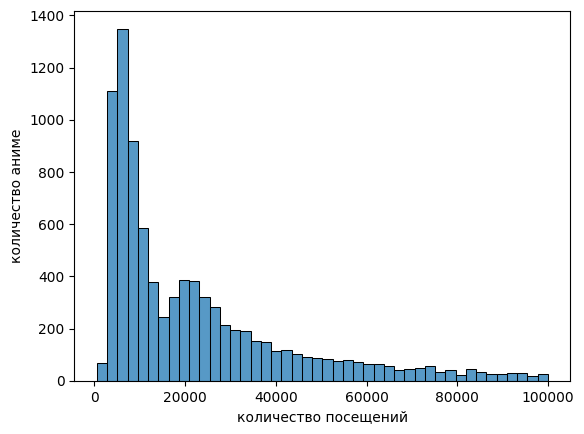

In [ ]:
mask1 = main_anime_df['views'] > 0
mask2 = main_anime_df['views'] < 1e5

sns.histplot(main_anime_df['views'].where(mask1 & mask2))


plt.title('')
plt.xlabel('количество посещений')
plt.ylabel('количество аниме')
plt.show()

In [122]:
mask1 = main_anime_df['views'] > 1e6

main_anime_df[mask1][['title', 'views']].sort_values(by='views', ascending=False).head(7)

,title,views
8017,Магическая битва: Смертельная миграция,11234866
8704,Гачиакута,9910383
7241,Адский рай 2,9204655
1201,Ван-Пис,9167028
101,Наруто: Ураганные хроники,6259384
79,Блич,5697901
7168,Ванпанчмен 3,5263528


(array([ 513.,    0.,    0.,    0.,    0.,  150.,    0.,    0.,    0.,
        9516.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

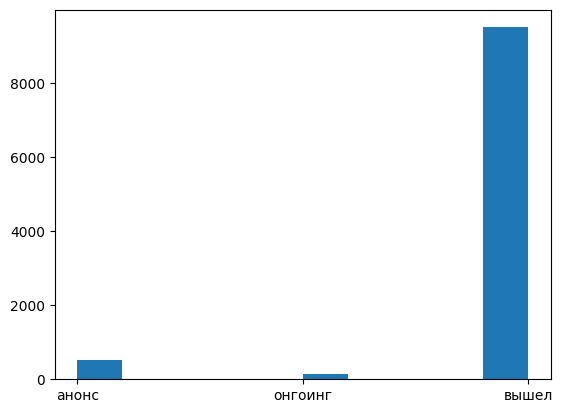

In [73]:
plt.hist(main_anime_df['anime_status_ru'])

In [107]:
time.date()

NameError: name 'time' is not defined

In [101]:
main_anime_df[main_anime_df['anime_status_ru'] == 'вышел']['year'].value_counts().sort_values()

year
1917      1
1960      1
1958      1
1961      1
1918      1
       ... 
2022    445
2021    453
2025    510
2024    516
2023    531
Name: count, Length: 84, dtype: int64

In [95]:
main_anime_df['anime_status_ru'].value_counts()

anime_status_ru
вышел      9516
анонс       513
онгоинг     150
Name: count, dtype: int64

(array([1326., 1732., 4159.,    0.,  376.,   95.,    0.,  819., 1367.,
         305.]),
 array([0. , 0.7, 1.4, 2.1, 2.8, 3.5, 4.2, 4.9, 5.6, 6.3, 7. ]),
 <BarContainer object of 10 artists>)

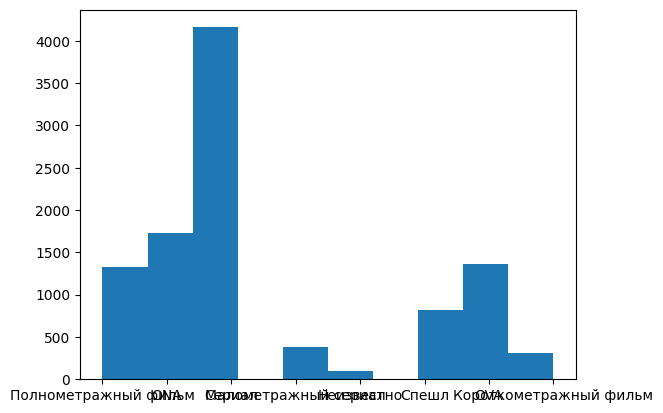

In [78]:
plt.hist(main_anime_df['type_ru'])
# plt.xlabel(rotation=90)

<Axes: xlabel='episodes_count', ylabel='Count'>

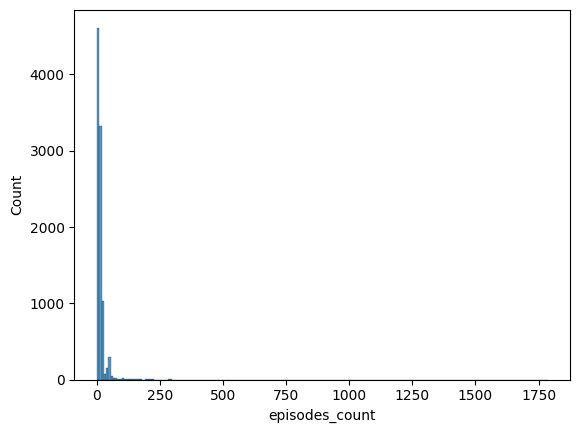

In [79]:
sns.histplot(main_anime_df['episodes_count'].where(main_anime_df['episodes_count']>0))

<Axes: xlabel='comments_count', ylabel='Count'>

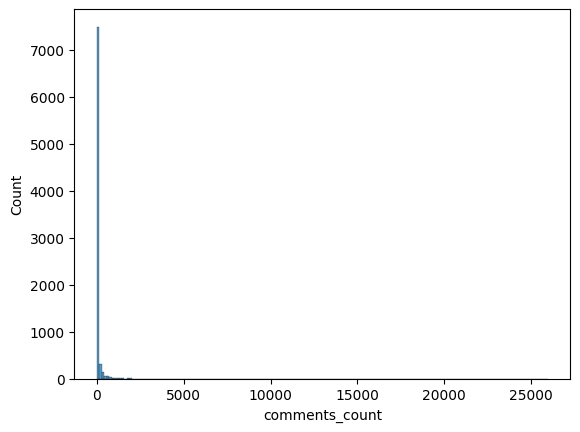

In [80]:
sns.histplot(main_anime_df['comments_count'].where(main_anime_df['comments_count']>0))

<Axes: xlabel='lists_count', ylabel='Count'>

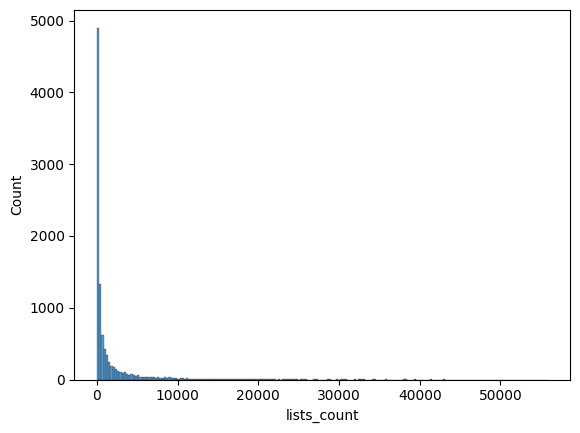

In [81]:
sns.histplot(main_anime_df['lists_count'].where(main_anime_df['lists_count']>0))


In [68]:
main_anime_df

,anime_id,title,description,duration,anime_url,year,season,views,anime_status_ru,type_ru,...,rating_place_over_category,other_anime_names,creators,creadors_ids,studios,studios_id,original,episodes_count,comments_count,lists_count
0,28636,"Первородный грех Такопи: Спасибо, увидимся завтра",NaN,0,pervorodnyy-greh-takopi-spasibo-uvidimsya-zavtra,0,0,5161,анонс,Полнометражный фильм,...,318,"[""Takopi's Original Sin"", 'Takopii no Genzai: ...",['Ино Синъя'],[7561],['Enishiya'],[14158],Манга,1,8,169
1,28630,Чжун Куй,Чжун Куй из поколения в поколение тайно оберег...,0,chzhun-kuy,2026,0,2688,анонс,Полнометражный фильм,...,317,"['Liu Dai Zhongkui', 'Master Zhong', 'Zhong Ku...","['Юйси Ван', ' Шаньчуань Хуан']","[12529, 12530]",['HOTALL'],[77095],NaN,1,4,28
2,28619,Аватар: Семь Гаваней,"Действие происходит в мире, пережившем разруши...",0,avatar-sem-gavaney,2027,0,10805,анонс,ONA,...,285,['Avatar: Seven Havens'],"['Майкл Данте ДиМартино', ' Брайан Кониецко']","[12522, 12523]",[],[],Оригинальная идея,26,10,204
3,28618,Легенда о Вокс Макине 4,"Продолжение ""Легенда о Вокс Макине""",0,legenda-voks-makine-4,2026,2,17259,онгоинг,Сериал,...,1107,"['The Legend of Vox Machina 4', 'Легенда Вокс ...",['Сон Джин Ан'],[8036],[],[],Игра,0,2,191
4,28617,"Добро пожаловать, Скуби-Ду!",Во время кулинарного приключения мечты в Япони...,0,dobro-pozhalovat-skubi-du,2027,0,5362,анонс,ONA,...,284,['Yokoso Scooby-Doo!'],['Ицуро Кавасаки'],[8129],['OLM'],[72],NaN,0,9,103
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10174,5,A3! Весна и лето,"Театр «Манкай» находится на грани разорения, н...",17149,a3-vesna-i-leto,2020,1,27622,вышел,Сериал,...,2067,"['A3! Season Spring & Summer', 'A3! Весна і лі...",['Кэйсукэ Синохара'],[7268],"['P.A. Works', 'Studio 3Hz']","[23, 578]",Игра,12,0,679
10175,4,A3! Осень и зима,"Компания «Манкай» далека от тех славных дней, ...",17124,a3-osen-i-zima,2020,4,32172,вышел,Сериал,...,2706,"['A3! Season Autumn & Winter', 'A3! Осінь та з...",['Сакой Масаюки'],[6],"['P.A. Works', 'Studio 3Hz']","[23, 578]",Игра,12,3,382
10176,3,"А ты думал, что твоя жена в онлайн-игре на сам...",В центре сюжета как обычно простой школьник-по...,17711,a-ty-dumal-chto-tvoya-zhena-v-onlajn-igre-na-s...,2016,2,240700,вышел,Сериал,...,4056,['And You Thought There Is Never a Girl Online...,['Янаги Синсукэ'],[5],['Project No.9'],[7],Ранобэ,12,149,9270
10177,2,5 сантиметров в секунду,"Что происходит, когда два человека любят друг ...",3766,5-santimetrov-v-sekundu,2007,2,254231,вышел,Полнометражный фильм,...,1176,"['5 Centimeters per Second', '5 сантиметрів на...",['Синкай Макото'],[4],['CoMix Wave Films'],[6],Оригинальная идея,1,264,14233


# genres

In [124]:
genres_df = pd.read_sql_query(
    '''
    SELECT *
    FROM genres
    ORDER BY anime_id
    ''',
    posgdb.conn
)

genres_copy = genres_df.copy()

C:\Users\gusen\AppData\Local\Temp\ipykernel_22972\1459233540.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  genres_df = pd.read_sql_query(


In [125]:
genres_df.head()

,anime_id,genre_id,title_ru,title_en,url
0,1,32,Приключения,priklyucheniya,/catalog/category/priklyucheniya
1,1,42,Фэнтези,fentezi,/catalog/category/fentezi
2,1,47,Ведьмы,ved-my,/catalog/category/ved-my
3,2,10,Сэйнэн,sejnen,/catalog/category/sejnen
4,2,15,Драма,drama,/catalog/category/drama


In [126]:
genres_copy.groupby('anime_id').count()

,genre_id,title_ru,title_en,url
anime_id,,,,
1,3,3,3,3
2,5,5,5,5
3,6,6,6,6
4,2,2,2,2
5,4,4,4,4
...,...,...,...,...
29077,3,3,3,3
29078,5,5,5,5
29117,5,5,5,5


# videos

In [127]:
videos_df = pd.read_sql_query(
    '''
    SELECT *
    FROM videos
    ORDER BY anime_id
    ''',
    posgdb.conn
)

videos_copy = videos_df.copy()

C:\Users\gusen\AppData\Local\Temp\ipykernel_22972\2793606113.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  videos_df = pd.read_sql_query(


In [128]:
videos_copy.groupby('anime_id').count()

,video_id,episode_number,player_id,player_name,dubbing_name,date,vid_index,views,duration
anime_id,,,,,,,,,
1,2,2,2,2,2,2,2,2,2
2,6,6,6,6,6,2,6,6,6
3,168,168,168,168,168,48,168,168,168
4,60,60,60,60,60,42,60,60,60
5,75,75,75,75,75,75,75,75,75
...,...,...,...,...,...,...,...,...,...
28708,1,1,1,1,1,1,1,1,1
28819,13,13,13,13,13,13,13,13,13
28932,1,1,1,1,1,1,1,1,1


In [130]:
videos_copy['episode_number'].value_counts()

episode_number
1        55323
2        45762
3        44099
4        42891
5        41697
         ...  
20a          1
20b          1
24.5         1
1-22         1
23-33        1
Name: count, Length: 1329, dtype: int64